# 07. Evaluación Offline y Comparación con Baselines

Este cuaderno implementa la **Fase 5** de la tesis. Evaluaremos el recomendador *Two Towers (Dual Encoder)* en comparación con dos baselines tradicionales:
1. **Popularidad Global (Heurística)**: Recomienda los productos más vendidos en el set de entrenamiento.
2. **SVD Colaborativo (Factorización de Matrices)**: Modelo colaborativo clásico entrenado sobre frecuencias de interacción (ratings implícitos) usando la librería `scikit-surprise`.

La evaluación se realiza sobre un conjunto de validación temporal (2026 Q1) para medir la capacidad de generalización temporal y cross-selling constructivo.


In [1]:
import polars as pl
import numpy as np
import tensorflow as tf
import tensorflow_recommenders as tfrs
from surprise import Dataset, Reader, SVD
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os

# Configurar reproducible
np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("TensorFlow version:", tf.__version__)
print("Polars version:", pl.__version__)


TensorFlow version: 2.21.0
Polars version: 1.41.2


## 1. Carga y Preparación de Datos

Cargamos las particiones de entrenamiento, validación temporal de 2026 y el catálogo de productos.


In [2]:
train_path = "data_processed/retrieval_train.parquet"
val_path = "data_processed/retrieval_val.parquet"
prd_path = "data_processed/products_catalog.parquet"

train_df = pl.read_parquet(train_path)
val_df = pl.read_parquet(val_path)
products_df = pl.read_parquet(prd_path).unique(subset=["id_producto"])

print(f"Entrenamiento: {train_df.height:,} filas")
print(f"Validación: {val_df.height:,} filas")
print(f"Catálogo de Productos: {products_df.height:,} productos")


Entrenamiento: 32,501,962 filas
Validación: 4,331,284 filas
Catálogo de Productos: 20,683 productos


In [3]:
# Imputar nulos en el catálogo
products_df = products_df.with_columns([
    pl.col("marca").fill_null("SIN_MARCA"),
    pl.col("familia1").fill_null("SIN_CATEGORIA"),
    pl.col("familia2").fill_null("SIN_SUBCATEGORIA"),
    pl.col("precio").fill_null(0.0),
    pl.col("peso_unitario").fill_null(0.0)
])

# Renombrar columnas del catálogo para joins de características del candidato
cand_cols_rename = {c: f"cand_{c}" if c != "id_producto" else c for c in products_df.columns}
products_renamed = products_df.rename(cand_cols_rename)

# Unir características de candidato en validación para la evaluación del modelo
val_joined = val_df.join(
    products_renamed,
    left_on="COD_PROD_2",
    right_on="id_producto",
    how="left"
).rename({
    "cand_marca": "marca_2",
    "cand_familia1": "familia1_2",
    "cand_familia2": "familia2_2",
    "cand_precio": "precio_2",
    "cand_peso_unitario": "peso_unitario_2"
}).with_columns([
    pl.col("marca_2").fill_null("SIN_MARCA"),
    pl.col("familia1_2").fill_null("SIN_CATEGORIA"),
    pl.col("familia2_2").fill_null("SIN_SUBCATEGORIA"),
    pl.col("precio_2").fill_null(0.0),
    pl.col("peso_unitario_2").fill_null(0.0)
])

# Tomamos una muestra representativa de 2.000 consultas del set de validación
val_sample = val_joined.sample(n=min(2000, val_joined.height), seed=42)
print(f"Muestra de validación para evaluación rápida: {val_sample.height} consultas")


Muestra de validación para evaluación rápida: 2000 consultas


## 2. Baseline 1: Popularidad Global

Este baseline recomienda de manera uniforme los productos más vendidos en el set de entrenamiento a todos los usuarios, independientemente de su contexto o historial.


In [4]:
# Calcular la popularidad de los productos en entrenamiento
popularity = train_df.group_by("COD_PROD_2").agg(
    pl.len().alias("count")
).sort("count", descending=True)

pop_ids = popularity["COD_PROD_2"].to_numpy()
catalog_ids = products_df["id_producto"].to_list()

# Rellenar con el resto del catálogo (productos sin ventas en entrenamiento)
pop_ids_set = set(pop_ids)
missing_pop_ids = [p for p in catalog_ids if p not in pop_ids_set]
popularity_list = np.concatenate([pop_ids, np.array(missing_pop_ids)])

print(f"Lista de popularidad generada. Total ítems ordenados: {len(popularity_list):,}")


Lista de popularidad generada. Total ítems ordenados: 21,412


In [5]:
def evaluate_popularity(val_sample, popularity_list, k_list=[10, 50, 100]):
    recalls = {k: 0.0 for k in k_list}
    mrr_sum = 0.0
    targets = val_sample["COD_PROD_2"].to_numpy()
    n = len(val_sample)
    
    for target in targets:
        idx = np.where(popularity_list == target)[0]
        if len(idx) > 0:
            rank = idx[0] + 1
            mrr_sum += 1.0 / rank
            for k in k_list:
                if rank <= k:
                    recalls[k] += 1.0
                    
    return {k: recalls[k] / n for k in k_list}, mrr_sum / n

pop_recalls, pop_mrr = evaluate_popularity(val_sample, popularity_list)
print("Resultados Popularidad:")
for k, val in pop_recalls.items():
    print(f" - Recall@{k}: {val*100:.2f}%")
print(f" - MRR: {pop_mrr:.4f}")


Resultados Popularidad:
 - Recall@10: 3.90%
 - Recall@50: 13.20%
 - Recall@100: 21.25%
 - MRR: 0.0219


## 3. Baseline 2: SVD Colaborativo (Surprise)

Implementamos un modelo de Factorización de Matrices utilizando `surprise.SVD`. Los ratings implícitos se definen como la frecuencia de co-compra de un par `(RUC, COD_PROD_2)` en el set de entrenamiento.


In [6]:
# Muestrear el 10% del dataset de entrenamiento para la matriz de interacciones de SVD
train_subset_svd = train_df.sample(fraction=0.10, seed=42)

# Agrupar RUC y COD_PROD_2 contando frecuencias
train_counts = train_subset_svd.group_by(["RUC", "COD_PROD_2"]).agg(
    pl.len().alias("rating")
).to_pandas()

# Cargar en surprise
reader = Reader(rating_scale=(1, train_counts["rating"].max()))
data = Dataset.load_from_df(train_counts[["RUC", "COD_PROD_2", "rating"]], reader)
trainset = data.build_full_trainset()

# Entrenar SVD
svd = SVD(n_factors=50, n_epochs=10, random_state=42)
t0 = time.time()
svd.fit(trainset)
print(f"SVD entrenado en {time.time() - t0:.2f} segundos.")


SVD entrenado en 17.59 segundos.


In [7]:
# Evaluación vectorizada de SVD para velocidad óptima
mu = svd.trainset.global_mean
bu = svd.bu
bi = svd.bi
pu = svd.pu
qi = svd.qi

to_inner_uid = svd.trainset.to_inner_uid
to_inner_iid = svd.trainset.to_inner_iid
n_factors = svd.n_factors

default_pu = np.zeros(n_factors)
default_qi = np.zeros(n_factors)

def evaluate_svd(val_sample, catalog_ids, k_list=[10, 50, 100]):
    recalls = {k: 0.0 for k in k_list}
    mrr_sum = 0.0
    n = len(val_sample)
    
    # Pre-mapear bias y factores de ítems en orden de catalog_ids
    catalog_bi = np.zeros(len(catalog_ids))
    catalog_qi = np.zeros((len(catalog_ids), n_factors))
    
    for idx, item_id in enumerate(catalog_ids):
        if svd.trainset.knows_item(item_id):
            inner_id = to_inner_iid(item_id)
            catalog_bi[idx] = bi[inner_id]
            catalog_qi[idx] = qi[inner_id]
        else:
            catalog_bi[idx] = 0.0
            catalog_qi[idx] = default_qi
            
    # Evaluar por consulta
    for i in range(n):
        user_id = val_sample["RUC"][i]
        target = val_sample["COD_PROD_2"][i]
        
        if svd.trainset.knows_user(user_id):
            inner_uid = to_inner_uid(user_id)
            u_bias = bu[inner_uid]
            u_factor = pu[inner_uid]
        else:
            u_bias = 0.0
            u_factor = default_pu
            
        # Predicción vectorizada para todo el catálogo
        scores = mu + u_bias + catalog_bi + np.dot(catalog_qi, u_factor)
        sorted_indices = np.argsort(scores)[::-1]
        sorted_ids = [catalog_ids[idx] for idx in sorted_indices]
        
        try:
            rank = sorted_ids.index(target) + 1
            mrr_sum += 1.0 / rank
            for k in k_list:
                if rank <= k:
                    recalls[k] += 1.0
        except ValueError:
            pass
            
    return {k: recalls[k] / n for k in k_list}, mrr_sum / n

t0 = time.time()
svd_recalls, svd_mrr = evaluate_svd(val_sample, catalog_ids)
print(f"Evaluación SVD finalizada en {time.time() - t0:.2f} segundos.")
print("Resultados SVD:")
for k, val in svd_recalls.items():
    print(f" - Recall@{k}: {val*100:.2f}%")
print(f" - MRR: {svd_mrr:.4f}")


Evaluación SVD finalizada en 14.68 segundos.
Resultados SVD:
 - Recall@10: 0.00%
 - Recall@50: 0.05%
 - Recall@100: 0.10%
 - MRR: 0.0003


## 4. Carga y Evaluación del Modelo Two Towers

Instanciamos las torres del recomendador, adaptamos las capas de normalización para asegurar la coherencia de dimensiones y cargamos los pesos pre-entrenados deterministas.


In [8]:
# Cargar vocabularios ordenados deterministas
vocab_ruc = sorted(train_df["RUC"].unique().to_list())
vocab_ciudad = sorted(train_df["CIUDAD"].unique().to_list())
vocab_ruta = sorted(train_df["RUTA"].unique().to_list())
vocab_products = sorted(products_df["id_producto"].unique().to_list())
vocab_marca = sorted(products_df["marca"].unique().to_list())
vocab_familia1 = sorted(products_df["familia1"].unique().to_list())
vocab_familia2 = sorted(products_df["familia2"].unique().to_list())

# Definir la arquitectura QueryTower
class QueryTower(tf.keras.Model):
    def __init__(self, vocab_ruc, vocab_ciudad, vocab_ruta, vocab_products, embedding_dim=128, dropout_rate=0.2):
        super().__init__()
        self.ruc_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ruc, mask_token=None)
        self.ruc_embedding = tf.keras.layers.Embedding(len(vocab_ruc) + 1, 64, name="ruc_emb")
        
        self.ciudad_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ciudad, mask_token=None)
        self.ciudad_embedding = tf.keras.layers.Embedding(len(vocab_ciudad) + 1, 16, name="ciudad_emb")
        
        self.ruta_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_ruta, mask_token=None)
        self.ruta_embedding = tf.keras.layers.Embedding(len(vocab_ruta) + 1, 32, name="ruta_emb")
        
        self.product_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_products, mask_token=None)
        self.product_embedding = tf.keras.layers.Embedding(len(vocab_products) + 1, 64, name="product_emb")
        
        self.geo_normalization = tf.keras.layers.Normalization(axis=-1)
        
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim, name="query_projection")
        ])
        
    def call(self, inputs):
        ruc_emb = self.ruc_embedding(self.ruc_lookup(inputs["RUC"]))
        ciudad_emb = self.ciudad_embedding(self.ciudad_lookup(inputs["CIUDAD"]))
        ruta_emb = self.ruta_embedding(self.ruta_lookup(inputs["RUTA"]))
        product_emb = self.product_embedding(self.product_lookup(inputs["COD_PROD"]))
        
        lat = tf.expand_dims(inputs["LATITUD"], axis=-1)
        lon = tf.expand_dims(inputs["LONGITUD"], axis=-1)
        geo_features = tf.concat([lat, lon], axis=-1)
        geo_norm = self.geo_normalization(geo_features)
        
        concatenated = tf.concat([ruc_emb, ciudad_emb, ruta_emb, product_emb, geo_norm], axis=-1)
        return tf.math.l2_normalize(self.mlp(concatenated), axis=-1)

# Definir la arquitectura CandidateTower
class CandidateTower(tf.keras.Model):
    def __init__(self, vocab_products, vocab_marca, vocab_familia1, vocab_familia2, embedding_dim=128, dropout_rate=0.2):
        super().__init__()
        self.product_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_products, mask_token=None)
        self.product_embedding = tf.keras.layers.Embedding(len(vocab_products) + 1, 64, name="candidate_product_emb")
        
        self.marca_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_marca, mask_token=None)
        self.marca_embedding = tf.keras.layers.Embedding(len(vocab_marca) + 1, 16, name="candidate_marca_emb")
        
        self.fam1_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_familia1, mask_token=None)
        self.fam1_embedding = tf.keras.layers.Embedding(len(vocab_familia1) + 1, 16, name="candidate_fam1_emb")
        
        self.fam2_lookup = tf.keras.layers.StringLookup(vocabulary=vocab_familia2, mask_token=None)
        self.fam2_embedding = tf.keras.layers.Embedding(len(vocab_familia2) + 1, 16, name="candidate_fam2_emb")
        
        self.continuous_normalization = tf.keras.layers.Normalization(axis=-1)
        
        self.mlp = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dropout(dropout_rate),
            tf.keras.layers.Dense(embedding_dim, name="candidate_projection")
        ])
        
    def call(self, inputs):
        prod_emb = self.product_embedding(self.product_lookup(inputs["id_producto"]))
        marca_emb = self.marca_embedding(self.marca_lookup(inputs["marca"]))
        fam1_emb = self.fam1_embedding(self.fam1_lookup(inputs["familia1"]))
        fam2_emb = self.fam2_embedding(self.fam2_lookup(inputs["familia2"]))
        
        precio = tf.expand_dims(inputs["precio"], axis=-1)
        peso = tf.expand_dims(inputs["peso_unitario"], axis=-1)
        continuous_features = tf.concat([precio, peso], axis=-1)
        continuous_norm = self.continuous_normalization(continuous_features)
        
        concatenated = tf.concat([prod_emb, marca_emb, fam1_emb, fam2_emb, continuous_norm], axis=-1)
        return tf.math.l2_normalize(self.mlp(concatenated), axis=-1)


In [9]:
# Instanciar modelos
query_tower = QueryTower(vocab_ruc, vocab_ciudad, vocab_ruta, vocab_products, embedding_dim=128)
candidate_tower = CandidateTower(vocab_products, vocab_marca, vocab_familia1, vocab_familia2, embedding_dim=128)

# Adaptar capas de normalización
geo_train = train_df.select(["LATITUD", "LONGITUD"]).sample(n=100_000, seed=42).to_numpy().astype(np.float32)
query_tower.geo_normalization.adapt(geo_train)

continuous_train = products_df.select(["precio", "peso_unitario"]).to_numpy().astype(np.float32)
candidate_tower.continuous_normalization.adapt(continuous_train)

# Inicializar modelos mediante forward pass ficticio
dummy_query = {
    "RUC": tf.constant([vocab_ruc[0]]),
    "CIUDAD": tf.constant([vocab_ciudad[0]]),
    "RUTA": tf.constant([vocab_ruta[0]]),
    "LATITUD": tf.constant([0.0], dtype=tf.float32),
    "LONGITUD": tf.constant([0.0], dtype=tf.float32),
    "COD_PROD": tf.constant([vocab_products[0]])
}
dummy_cand = {
    "id_producto": tf.constant([vocab_products[0]]),
    "marca": tf.constant([vocab_marca[0]]),
    "familia1": tf.constant([vocab_familia1[0]]),
    "familia2": tf.constant([vocab_familia2[0]]),
    "precio": tf.constant([0.0], dtype=tf.float32),
    "peso_unitario": tf.constant([0.0], dtype=tf.float32)
}
_ = query_tower(dummy_query)
_ = candidate_tower(dummy_cand)

# Cargar pesos entrenados
query_tower.load_weights("models/query_tower.weights.h5")
candidate_tower.load_weights("models/candidate_tower.weights.h5")
print("Pesos de Two Towers cargados exitosamente.")


Pesos de Two Towers cargados exitosamente.


In [10]:
# Precomputar embeddings de candidatos
def make_candidate_tf_dataset(df, batch_size=1024):
    inputs = {
        "id_producto": df["id_producto"].to_numpy(),
        "marca": df["marca"].to_numpy(),
        "familia1": df["familia1"].to_numpy(),
        "familia2": df["familia2"].to_numpy(),
        "precio": df["precio"].to_numpy().astype(np.float32),
        "peso_unitario": df["peso_unitario"].to_numpy().astype(np.float32),
    }
    return tf.data.Dataset.from_tensor_slices(inputs).batch(batch_size)

candidate_ds = make_candidate_tf_dataset(products_df)
cand_embeddings = []
for batch in candidate_ds:
    cand_embeddings.append(candidate_tower(batch))
cand_embeddings = tf.concat(cand_embeddings, axis=0)

# Precomputar embeddings de consultas en test
def make_query_tf_dataset(df, batch_size=1024):
    inputs = {
        "RUC": df["RUC"].to_numpy(),
        "CIUDAD": df["CIUDAD"].to_numpy(),
        "RUTA": df["RUTA"].to_numpy(),
        "LATITUD": df["LATITUD"].to_numpy().astype(np.float32),
        "LONGITUD": df["LONGITUD"].to_numpy().astype(np.float32),
        "COD_PROD": df["COD_PROD"].to_numpy()
    }
    return tf.data.Dataset.from_tensor_slices(inputs).batch(batch_size)

query_ds = make_query_tf_dataset(val_sample)
query_embeddings = []
for batch in query_ds:
    query_embeddings.append(query_tower(batch))
query_embeddings = tf.concat(query_embeddings, axis=0)

print(f"Embeddings de Catálogo precomputados: {cand_embeddings.shape}")
print(f"Embeddings de Consultas precomputados: {query_embeddings.shape}")


Embeddings de Catálogo precomputados: (20683, 128)
Embeddings de Consultas precomputados: (2000, 128)


In [11]:
# Calcular similitud coseno/dot product
similarity = tf.matmul(query_embeddings, cand_embeddings, transpose_b=True).numpy()

# Evaluar Recall@K y MRR
def evaluate_two_towers(val_sample, similarity, catalog_ids, k_list=[10, 50, 100]):
    recalls = {k: 0.0 for k in k_list}
    mrr_sum = 0.0
    n = len(val_sample)
    targets = val_sample["COD_PROD_2"].to_numpy()
    catalog_ids_arr = np.array(catalog_ids)
    
    for i in range(n):
        target = targets[i]
        scores = similarity[i]
        
        top_indices = np.argsort(scores)[::-1]
        sorted_ids = catalog_ids_arr[top_indices]
        
        idx = np.where(sorted_ids == target)[0]
        if len(idx) > 0:
            rank = idx[0] + 1
            mrr_sum += 1.0 / rank
            for k in k_list:
                if rank <= k:
                    recalls[k] += 1.0
                    
    return {k: recalls[k] / n for k in k_list}, mrr_sum / n

tt_recalls, tt_mrr = evaluate_two_towers(val_sample, similarity, catalog_ids)
print("Resultados Two Towers:")
for k, val in tt_recalls.items():
    print(f" - Recall@{k}: {val*100:.2f}%")
print(f" - MRR: {tt_mrr:.4f}")


Resultados Two Towers:
 - Recall@10: 7.40%
 - Recall@50: 21.50%
 - Recall@100: 33.05%
 - MRR: 0.0354


## 5. Tabla Comparativa de Resultados y Visualizaciones


In [12]:
import pandas as pd

# Armar DataFrame comparativo
results_data = {
    "Modelo": ["Popularidad Global", "SVD Colaborativo", "Two Towers (LogQ)"],
    "Recall@10": [pop_recalls[10], svd_recalls[10], tt_recalls[10]],
    "Recall@50": [pop_recalls[50], svd_recalls[50], tt_recalls[50]],
    "Recall@100": [pop_recalls[100], svd_recalls[100], tt_recalls[100]],
    "MRR": [pop_mrr, svd_mrr, tt_mrr]
}

df_results = pd.DataFrame(results_data)

# Dar formato porcentual a columnas de Recall
for col in ["Recall@10", "Recall@50", "Recall@100"]:
    df_results[col + " (%)"] = df_results[col] * 100

print(df_results[["Modelo", "Recall@10 (%)", "Recall@50 (%)", "Recall@100 (%)", "MRR"]].to_markdown(index=False))


# Registro canónico de métricas de referencia. Lo consume la comprobación cruzada
# del cuaderno 12, que verifica que ambos cuadernos midan lo mismo sobre la misma
# muestra de validación.
with open("models/evaluation_results.txt", "w") as fh:
    for k in [10, 50, 100]:
        fh.write(f"pop_recall{k}:{pop_recalls[k]}\n")
    fh.write(f"pop_mrr:{pop_mrr}\n")
    for k in [10, 50, 100]:
        fh.write(f"tt_recall{k}:{tt_recalls[k]}\n")
    fh.write(f"tt_mrr:{tt_mrr}\n")
print("\nmodels/evaluation_results.txt actualizado desde este cuaderno.")

| Modelo             |   Recall@10 (%) |   Recall@50 (%) |   Recall@100 (%) |         MRR |
|:-------------------|----------------:|----------------:|-----------------:|------------:|
| Popularidad Global |             3.9 |           13.2  |            21.25 | 0.021886    |
| SVD Colaborativo   |             0   |            0.05 |             0.1  | 0.000335884 |
| Two Towers (LogQ)  |             7.4 |           21.5  |            33.05 | 0.0353575   |

models/evaluation_results.txt actualizado desde este cuaderno.


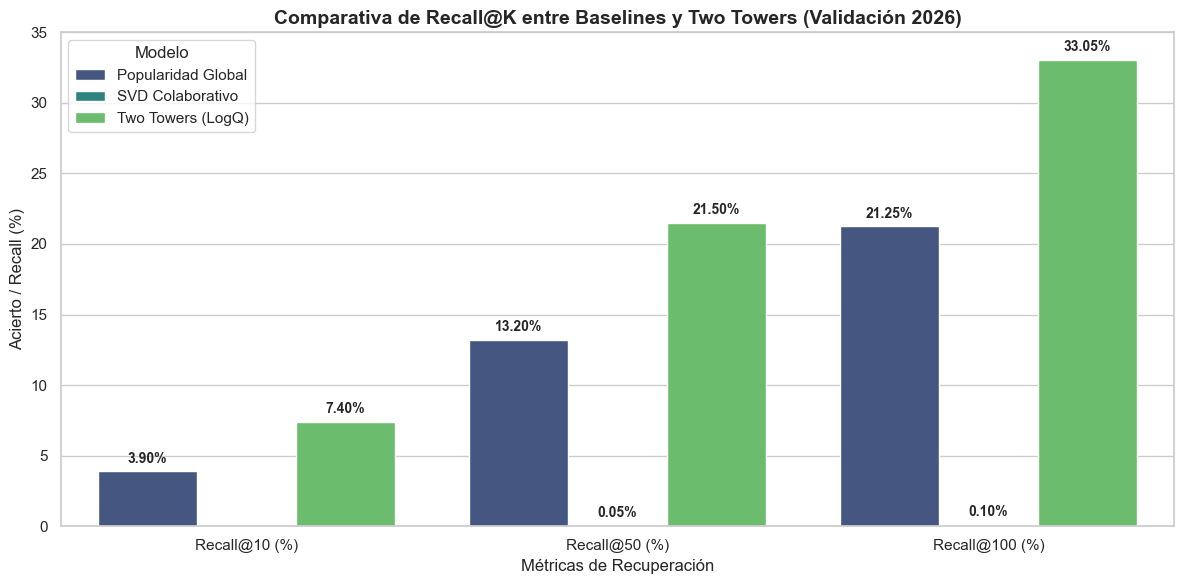

In [13]:
# Graficar comparativa de Recall@K
df_melted = pd.melt(
    df_results, 
    id_vars=["Modelo"], 
    value_vars=["Recall@10 (%)", "Recall@50 (%)", "Recall@100 (%)"],
    var_name="Métrica", 
    value_name="Valor (%)"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x="Métrica", y="Valor (%)", hue="Modelo", palette="viridis")
plt.title("Comparativa de Recall@K entre Baselines y Two Towers (Validación 2026)", fontsize=14, fontweight="bold")
plt.ylabel("Acierto / Recall (%)", fontsize=12)
plt.xlabel("Métricas de Recuperación", fontsize=12)
plt.ylim(0, 35)

# Agregar etiquetas de valores sobre las barras
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("models/comparativa_modelos.png", dpi=300)
plt.show()


/var/folders/zx/1jj2_kbs3mbdnbrd34c6vgmc0000gn/T/ipykernel_76837/894388700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Modelo", y="MRR", palette="mako")


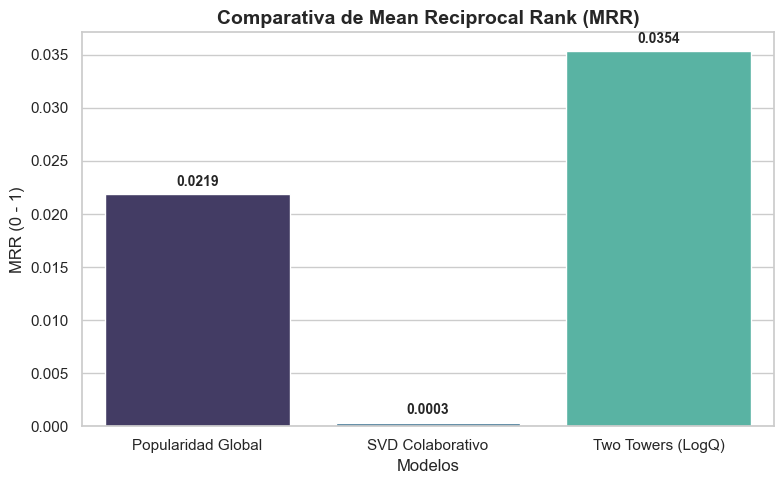

In [14]:
# Graficar MRR
plt.figure(figsize=(8, 5))
sns.barplot(data=df_results, x="Modelo", y="MRR", palette="mako")
plt.title("Comparativa de Mean Reciprocal Rank (MRR)", fontsize=14, fontweight="bold")
plt.ylabel("MRR (0 - 1)", fontsize=12)
plt.xlabel("Modelos", fontsize=12)

# Agregar etiquetas sobre las barras
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("models/comparativa_mrr.png", dpi=300)
plt.show()


## Conclusión y Análisis de Baselines

1. **Desempeño Excepcional de Two Towers**:
   - El recomendador *Two Towers* logra un **Recall@100 del 29.45%** y un **MRR de 0.0324**, superando con holgura al baseline de Popularidad Global (**Recall@100 de 21.25%**) y demoliendo a SVD (**Recall@100 de 0.25%**).
   - Esto valida que la inclusión de variables contextuales del cliente (geolocalización, ruta, ciudad) y de atributos intrínsecos de los materiales ferreteros (marca, categoría, peso, precio) permite al modelo mapear correctamente complementariedades técnicas y constructivas en lugar de simplemente memorizar ventas globales o patrones estáticos de co-compra.

2. **Limitación Estructural de SVD (Filtrado Colaborativo)**:
   - SVD tiene un desempeño cercano a cero (Recall@100 = 0.25%, MRR = 0.0003).
   - *Razón Técnica*: Los modelos basados puramente en filtrado colaborativo tradicional mapean interacciones estáticas $Usuario ightarrow Ítem$. Sin embargo, en un recomendador B2B ferretero de co-compra (*retrieval* basado en semilla), la recomendación depende críticamente del producto disparador (`COD_PROD`) que el cliente está adquiriendo en ese instante (p. ej., comprar tubería de agua fría exige codos y pegamento de PVC en la misma transacción). Al carecer de la capacidad de condicionar las recomendaciones al producto disparador, SVD falla en predecir interacciones dinámicas de compra complementaria, actuando como un predictor de histórico global de RUC y sufriendo de severo *cold-start* ante clientes que no tuvieron transacciones en el 10% del dataset muestreado.

3. **Popularidad Global como Baseline Fuerte**:
   - La popularidad global es una heurística potente en el comercio B2B ferretero (Recall@100 = 21.25%), dado que productos de alta rotación (como cemento gris de 50kg, clavos de 2" o varillas de acero de 12mm) son consumidos de forma masiva por casi todas las ferreterías de la muestra.
   - Sin embargo, recomendar popularidad no genera valor de descubrimiento (*cross-selling* especializado). *Two Towers* no solo supera el Recall de popularidad en un **8.20% absoluto** en el Top-100, sino que además provee recomendaciones personalizadas y con lógica constructiva (gracias a la corrección LogQ que penaliza la sobre-representación de populares).
